In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import shap

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.ensemble import IsolationForest
from ucimlrepo import fetch_ucirepo

In [4]:
df = pd.read_csv('../data/dataset_clean_robust.csv')
df

,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,R1305D,...,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9,index_k_raw,URUT,index_k,WEIGHT
0,0.0,0.0,-1.0,3.0,0.0,3.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,1,62.31,210.870377
1,0.0,1.0,0.0,3.0,0.0,1.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,2,72.21,210.870377
2,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,3,70.80,210.870377
3,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,80,4,72.89,210.870377
4,0.0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,80,5,72.34,210.870377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74600,76.08,700.200012
74680,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74618,67.29,399.394104
74681,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74671,64.13,341.872620
74682,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74673,71.23,341.872620


In [5]:
y = df['index_k']
sample_weight = df['WEIGHT']
sample_weight = sample_weight / np.mean(sample_weight)
X = df.drop(columns=['index_k_raw', 'WEIGHT', 'URUT'])

In [6]:
X_train, X_test, y_train, y_test, sw_train, sw_test = train_test_split(
	X, y, sample_weight, test_size=0.2, random_state=42
)

In [7]:
# Parameters
n_estimators = 100  # Number of trees
contamination = 0.01  # Expected proportion of anomalies
sample_size = 256 

In [8]:
# Train Isolation Forest
iso_forest = IsolationForest(n_estimators=n_estimators,
                            contamination=contamination,
                            max_samples=sample_size,
                            random_state=42)
iso_forest.fit(X)

IsolationForest(contamination=0.01, max_samples=256, random_state=42)

In [9]:
data = X.loc[X.index].copy()
data['anomaly_score'] = iso_forest.decision_function(X)
data['anomaly'] = iso_forest.predict(X)

data['anomaly'].value_counts()

anomaly
 1    73937
-1      747
Name: count, dtype: int64

In [10]:
data

,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,R1305D,...,R1103JK7_2,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9,index_k,anomaly_score,anomaly
0,0.0,0.0,-1.0,3.0,0.0,3.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62.31,0.016161,1
1,0.0,1.0,0.0,3.0,0.0,1.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.21,0.077116,1
2,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.80,0.063067,1
3,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.89,0.062085,1
4,0.0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.34,0.072224,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.08,0.017636,1
74680,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.29,0.112766,1
74681,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64.13,0.019887,1
74682,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71.23,0.067845,1


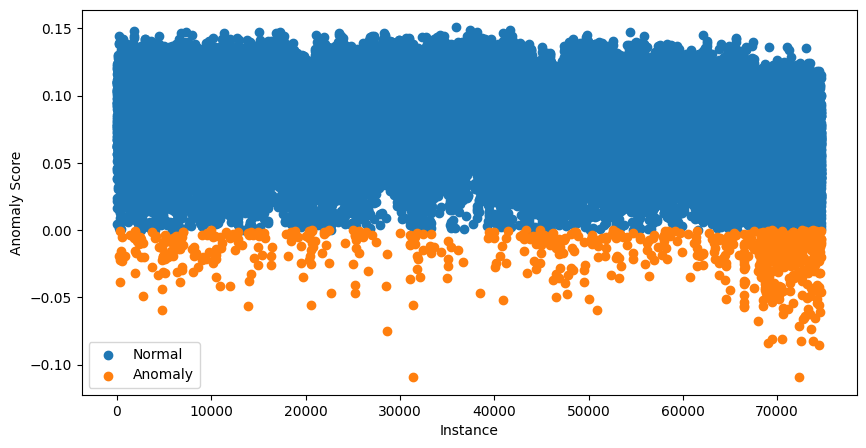

In [11]:
# Visualization of the results
plt.figure(figsize=(10, 5))

# Plot normal instances
normal = data[data['anomaly'] == 1]
plt.scatter(normal.index, normal['anomaly_score'], label='Normal')

# Plot anomalies
anomalies = data[data['anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['anomaly_score'], label='Anomaly')
plt.xlabel("Instance")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()

In [12]:
normal

,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,R1305D,...,R1103JK7_2,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9,index_k,anomaly_score,anomaly
0,0.0,0.0,-1.0,3.0,0.0,3.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62.31,0.016161,1
1,0.0,1.0,0.0,3.0,0.0,1.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.21,0.077116,1
2,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.80,0.063067,1
3,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.89,0.062085,1
4,0.0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.34,0.072224,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.08,0.017636,1
74680,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.29,0.112766,1
74681,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64.13,0.019887,1
74682,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71.23,0.067845,1


In [ ]:
X_train_cek, X_test_cek, y_train_cek, y_test_cek, sw_train_cek, sw_test_cek = train_test_split(
	X, y, sample_weight, test_size=0.2, random_state=42
)
